In [ ]:
!python --version

Python 3.13.15


In [ ]:
!pip install -q --no-cache-dir git+https://github.com/nilmtk/nilmtk.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 282.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 639.0/639.0 kB 270.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 300.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 279.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 268.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 247.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.17.1 

In [ ]:
import nilmtk
print("NILMTK WORKING ✅")
print(nilmtk.__version__)

NILMTK WORKING ✅
0.4.1


In [ ]:
import nilmtk.disaggregate as dis

print(dir(dis))

['CO', 'Disaggregator', 'FHMMExact', 'Hart85', 'Mean', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'combinatorial_optimisation', 'disaggregator', 'fhmm_exact', 'hart_85', 'mean']


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from nilmtk import DataSet, HDFDataStore
from nilmtk.dataset_converters import convert_iawe

from nilmtk.disaggregate import CO, FHMMExact

from nilmtk.metrics import f1_score

import pandas as pd
import matplotlib.pyplot as plt

print("Imports successful ✅")

Imports successful ✅


In [ ]:
import zipfile
import os

zip_path = "/content/electricity.zip"
extract_path = "/content/iawe"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted!")

Extracted!


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(root)
    print("Files:", files)
    print()

/content/iawe
Files: []

/content/iawe/electricity
Files: ['3.csv', '4.csv', '12.csv', '6.csv', 'labels.dat', '11.csv', '1.csv', '5.csv', '9.csv', '10.csv', '2.csv', '8.csv', '7.csv']



In [ ]:
iawe_path = "/content/iawe/electricity"

In [ ]:
import os
import pandas as pd

files = os.listdir(iawe_path)

print("Number of files:", len(files))
print("\nFirst 20 files:")
for f in files[:20]:
    print(f)

Number of files: 13

First 20 files:
3.csv
4.csv
12.csv
6.csv
labels.dat
11.csv
1.csv
5.csv
9.csv
10.csv
2.csv
8.csv
7.csv


In [ ]:
csv_files = [f for f in files if f.lower().endswith(".csv")]

sample_file = os.path.join(iawe_path, csv_files[0])

df = pd.read_csv(sample_file)

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

    timestamp      W    VAR     VA      f       V     PF      A
0  1370563200  0.111  2.483  2.486  50.07  235.07  0.045  0.011
1  1370563201  0.200  2.547  2.555  50.08  235.02  0.078  0.011
2  1370563202  0.152  2.480  2.485  50.08  234.98  0.061  0.011
3  1370563203  0.159  2.444  2.449  50.06  235.00  0.065  0.010
4  1370563204  0.215  2.510  2.519  50.06  234.95  0.085  0.011

Shape: (4538844, 8)

Columns:
['timestamp', 'W', 'VAR', 'VA', 'f', 'V', 'PF', 'A']

Data types:
timestamp      int64
W            float64
VAR          float64
VA           float64
f            float64
V            float64
PF           float64
A            float64
dtype: object

Missing values:
timestamp    0
W            0
VAR          0
VA           0
f            0
V            0
PF           0
A            0
dtype: int64


In [ ]:
print("Dataset shape:", df.shape)

print("\nFirst rows:")
display(df.head())

print("\nLast rows:")
display(df.tail())

print("\nSummary statistics:")
display(df.describe(include="all"))

Dataset shape: (4538844, 8)

First rows:


,timestamp,W,VAR,VA,f,V,PF,A
0,1370563200,0.111,2.483,2.486,50.07,235.07,0.045,0.011
1,1370563201,0.200,2.547,2.555,50.08,235.02,0.078,0.011
2,1370563202,0.152,2.480,2.485,50.08,234.98,0.061,0.011
3,1370563203,0.159,2.444,2.449,50.06,235.00,0.065,0.010
4,1370563204,0.215,2.510,2.519,50.06,234.95,0.085,0.011



Last rows:


,timestamp,W,VAR,VA,f,V,PF,A
4538839,1375720320,77.623,50.146,92.412,50.17,222.77,0.840,0.415
4538840,1375720321,77.604,50.490,92.584,50.18,222.78,0.838,0.416
4538841,1375720322,77.446,50.062,92.217,50.16,222.67,0.840,0.414
4538842,1375720323,77.414,50.387,92.367,50.18,222.69,0.838,0.415
4538843,1375720324,77.389,50.095,92.187,50.16,222.72,0.839,0.414



Summary statistics:


,timestamp,W,VAR,VA,f,V,PF,A
count,4.538844e+06,4.538844e+06,4.538844e+06,4.538844e+06,4.538844e+06,4.538844e+06,4.538844e+06,4.538844e+06
mean,1.373178e+09,5.951155e+01,3.881919e+01,7.177422e+01,5.008110e+01,2.322224e+02,5.621189e-01,3.145554e-01
std,1.489504e+06,4.665791e+01,2.866369e+01,5.380772e+01,1.357882e+00,1.181021e+01,4.060805e-01,7.741680e-01
min,1.370563e+09,0.000000e+00,-7.381000e+01,0.000000e+00,3.046000e+01,0.000000e+00,0.000000e+00,-2.262000e+00
25%,1.371908e+09,1.930000e-01,2.586000e+00,2.593000e+00,4.999000e+01,2.265500e+02,7.800000e-02,1.100000e-02
50%,1.373182e+09,7.976600e+01,5.306100e+01,9.859800e+01,5.007000e+01,2.339700e+02,7.950000e-01,4.250000e-01
75%,1.374481e+09,8.881600e+01,6.108900e+01,1.086690e+02,5.017000e+01,2.402600e+02,8.450000e-01,4.590000e-01
max,1.375720e+09,8.793080e+02,9.843050e+02,1.277104e+03,9.920000e+02,3.835800e+02,8.840500e+01,1.666500e+02


In [ ]:
print(df.columns)

Index(['timestamp', 'W', 'VAR', 'VA', 'f', 'V', 'PF', 'A'], dtype='object')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Make a copy so raw df remains untouched
analysis_df = df.copy()

# Convert Unix timestamp to datetime
analysis_df["datetime"] = pd.to_datetime(
    analysis_df["timestamp"],
    unit="s"
)

print("Start:", analysis_df["datetime"].min())
print("End:", analysis_df["datetime"].max())

print("\nTime difference between first two samples:")
print(
    analysis_df["datetime"].iloc[1]
    - analysis_df["datetime"].iloc[0]
)

print("\nNumber of unique timestamps:")
print(analysis_df["timestamp"].nunique())

print("\nDuplicate timestamps:")
print(analysis_df["timestamp"].duplicated().sum())

Start: 2013-06-07 00:00:00
End: 2013-08-05 16:32:04

Time difference between first two samples:
0 days 00:00:01

Number of unique timestamps:
4538844

Duplicate timestamps:
0


In [ ]:
time_diff = analysis_df["timestamp"].diff().dropna()

print("Most common sampling intervals:")
print(time_diff.value_counts().head(10))

print("\nMinimum interval:", time_diff.min())
print("Maximum interval:", time_diff.max())

Most common sampling intervals:
timestamp
1.0     4455873
2.0       34367
3.0       14261
4.0        8488
5.0        4659
8.0        4506
16.0       4368
9.0        4290
17.0       2954
29.0        732
Name: count, dtype: int64

Minimum interval: 1.0
Maximum interval: 12401.0


In [ ]:
gaps = time_diff[time_diff > 1]

print("Number of gaps > 1 second:", len(gaps))

if len(gaps) > 0:
    print("\nLargest gaps:")
    print(gaps.sort_values(ascending=False).head(10))

Number of gaps > 1 second: 82970

Largest gaps:
696938     12401.0
2499503    10842.0
4435654    10665.0
693240     10473.0
3329053     7817.0
282878      7415.0
892423      7375.0
1409797     7157.0
2600206     7001.0
2127009     6969.0
Name: timestamp, dtype: float64


In [ ]:
power_cols = ["W", "VAR", "VA", "f", "V", "PF", "A"]

print("Basic statistics:")
display(analysis_df[power_cols].describe().T)

Basic statistics:


,count,mean,std,min,25%,50%,75%,max
W,4538844.0,59.511546,46.657911,0.000,0.193,79.766,88.816,879.308
VAR,4538844.0,38.819187,28.663689,-73.810,2.586,53.061,61.089,984.305
VA,4538844.0,71.774224,53.807717,0.000,2.593,98.598,108.669,1277.104
f,4538844.0,50.081102,1.357882,30.460,49.990,50.070,50.170,992.000
V,4538844.0,232.222443,11.810212,0.000,226.550,233.970,240.260,383.580
PF,4538844.0,0.562119,0.406080,0.000,0.078,0.795,0.845,88.405
A,4538844.0,0.314555,0.774168,-2.262,0.011,0.425,0.459,166.650


In [ ]:
print("Negative active power (W):",
      (analysis_df["W"] < 0).sum())

print("Negative reactive power (VAR):",
      (analysis_df["VAR"] < 0).sum())

print("Zero active power (W):",
      (analysis_df["W"] == 0).sum())

print("Zero voltage (V):",
      (analysis_df["V"] == 0).sum())

print("Zero current (A):",
      (analysis_df["A"] == 0).sum())

print("PF outside [-1, 1]:",
      ((analysis_df["PF"] < -1) | (analysis_df["PF"] > 1)).sum())

Negative active power (W): 0
Negative reactive power (VAR): 7253
Zero active power (W): 198
Zero voltage (V): 10
Zero current (A): 0
PF outside [-1, 1]: 47


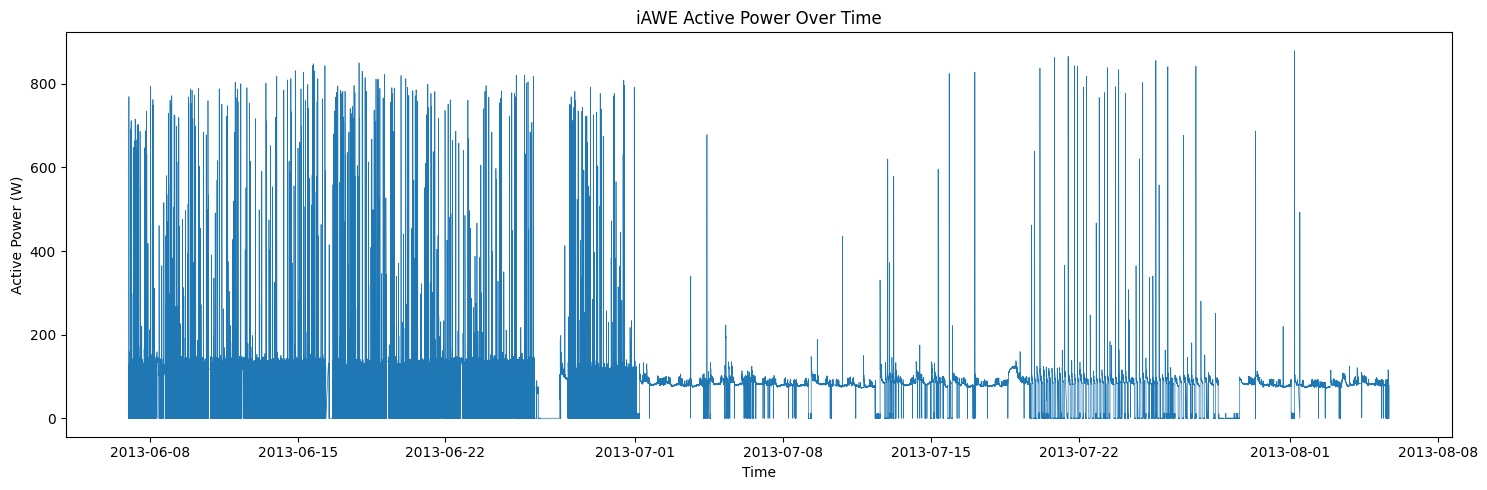

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    analysis_df["datetime"],
    analysis_df["W"],
    linewidth=0.5
)

plt.xlabel("Time")
plt.ylabel("Active Power (W)")
plt.title("iAWE Active Power Over Time")
plt.tight_layout()
plt.show()

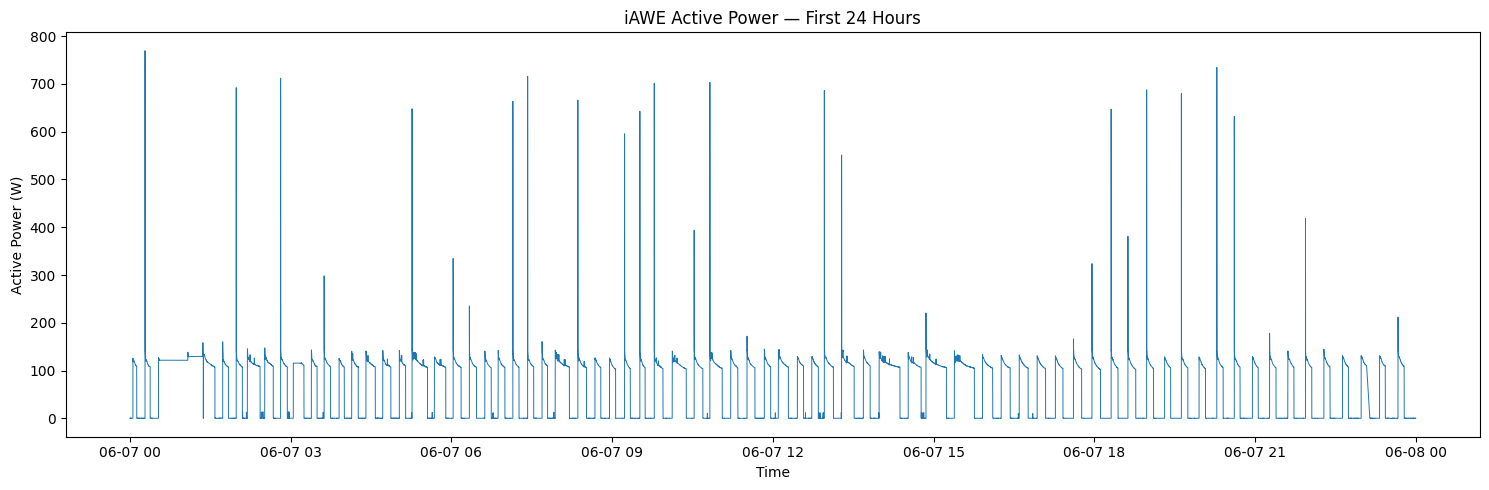

In [ ]:
first_day = analysis_df[
    analysis_df["datetime"] <
    analysis_df["datetime"].min() + pd.Timedelta(days=1)
]

plt.figure(figsize=(15, 5))

plt.plot(
    first_day["datetime"],
    first_day["W"],
    linewidth=0.7
)

plt.xlabel("Time")
plt.ylabel("Active Power (W)")
plt.title("iAWE Active Power — First 24 Hours")
plt.tight_layout()
plt.show()

In [ ]:
print("File:", sample_file)

print("\nMean active power:", df["W"].mean())
print("Median active power:", df["W"].median())
print("Maximum active power:", df["W"].max())

print("\nFirst timestamp:",
      analysis_df["datetime"].iloc[0])

print("Last timestamp:",
      analysis_df["datetime"].iloc[-1])

File: /content/iawe/electricity/3.csv

Mean active power: 59.51154622344366
Median active power: 79.766
Maximum active power: 879.308

First timestamp: 2013-06-07 00:00:00
Last timestamp: 2013-08-05 16:32:04


In [ ]:
for i, f in enumerate(csv_files):
    print(i, os.path.basename(f))

0 3.csv
1 4.csv
2 12.csv
3 6.csv
4 11.csv
5 1.csv
6 5.csv
7 9.csv
8 10.csv
9 2.csv
10 8.csv
11 7.csv


In [ ]:
print("Start:", analysis_df["datetime"].min())
print("End:", analysis_df["datetime"].max())
print("Number of unique timestamps:", analysis_df["timestamp"].nunique())
print("Duplicate timestamps:", analysis_df["timestamp"].duplicated().sum())

print("\nSampling intervals:")
print(time_diff.value_counts().head(10))

print("\nGaps > 1 second:", len(gaps))

Start: 2013-06-07 00:00:00
End: 2013-08-05 16:32:04
Number of unique timestamps: 4538844
Duplicate timestamps: 0

Sampling intervals:
timestamp
1.0     4455873
2.0       34367
3.0       14261
4.0        8488
5.0        4659
8.0        4506
16.0       4368
9.0        4290
17.0       2954
29.0        732
Name: count, dtype: int64

Gaps > 1 second: 82970


In [ ]:
import os
import pandas as pd

# Find all CSV files inside the extracted iAWE folder
iawe_path = "/content/iawe"

csv_files = []

for root, dirs, files in os.walk(iawe_path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("Found", len(csv_files), "CSV files:\n")

for f in sorted(csv_files):
    print(f)

Found 12 CSV files:

/content/iawe/electricity/1.csv
/content/iawe/electricity/10.csv
/content/iawe/electricity/11.csv
/content/iawe/electricity/12.csv
/content/iawe/electricity/2.csv
/content/iawe/electricity/3.csv
/content/iawe/electricity/4.csv
/content/iawe/electricity/5.csv
/content/iawe/electricity/6.csv
/content/iawe/electricity/7.csv
/content/iawe/electricity/8.csv
/content/iawe/electricity/9.csv


In [ ]:
import os
import pandas as pd

iawe_path = "/content/iawe"

# Find all CSVs
csv_files = []

for root, dirs, files in os.walk(iawe_path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

csv_files = sorted(csv_files)

print("CSV files found:", len(csv_files))
print()

# Check data types in every file
for file_path in csv_files:

    temp = pd.read_csv(file_path)

    print("=" * 60)
    print("FILE:", os.path.basename(file_path))
    print("Shape:", temp.shape)
    print("Columns:", temp.columns.tolist())
    print("Data types:")
    print(temp.dtypes)

CSV files found: 12

FILE: 1.csv
Shape: (4391059, 8)
Columns: ['timestamp', 'W', 'VAR', 'VA', 'f', 'VLN', 'PF', 'A']
Data types:
timestamp     int64
W            object
VAR          object
VA           object
f            object
VLN          object
PF           object
A            object
dtype: object
FILE: 10.csv
Shape: (428937, 8)
Columns: ['timestamp', 'W', 'VAR', 'VA', 'f', 'V', 'PF', 'A']
Data types:
timestamp      int64
W            float64
VAR          float64
VA           float64
f            float64
V            float64
PF           float64
A            float64
dtype: object
FILE: 11.csv
Shape: (1694622, 8)
Columns: ['timestamp', 'W', 'VAR', 'VA', 'f', 'V', 'PF', 'A']
Data types:
timestamp      int64
W            float64
VAR          float64
VA           float64
f            float64
V            float64
PF           float64
A            float64
dtype: object
FILE: 12.csv
Shape: (448809, 2)
Columns: ['timestamp', 'W']
Data types:
timestamp    int64
W            int64
dtype: obj

In [ ]:
for file_path in csv_files:

    temp = pd.read_csv(file_path)

    # Values in W that cannot be converted to numbers
    w_numeric = pd.to_numeric(temp["W"], errors="coerce")

    bad = temp[w_numeric.isna()]

    if len(bad) > 0:
        print("=" * 60)
        print("FILE:", os.path.basename(file_path))
        print("Number of non-numeric W values:", len(bad))
        print("\nExamples:")
        display(bad.head(10))

FILE: 1.csv
Number of non-numeric W values: 20

Examples:


,timestamp,W,VAR,VA,f,VLN,PF,A
102920,1369472888,\N,\N,\N,\N,\N,\N,\N
192914,1369572809,\N,\N,\N,\N,\N,\N,\N
331538,1369723145,\N,\N,\N,\N,\N,\N,\N
434944,1369837340,\N,\N,22.43,50.007,229.115005,\N,\N
573998,1370002782,\N,\N,\N,\N,\N,\N,\N
874475,1370517679,\N,\N,\N,\N,\N,\N,\N
890476,1370554495,\N,\N,\N,50.26720047,215.48899841,\N,\N
981219,1370679112,\N,\N,\N,\N,\N,\N,\N
984785,1370688982,\N,\N,\N,50.0,197.427994,\N,\N
1102865,1370868678,\N,\N,\N,\N,\N,\N,\N


FILE: 2.csv
Number of non-numeric W values: 48

Examples:


,timestamp,W,VAR,VA,f,VLN,PF,A
102920,1369472888,\N,\N,\N,\N,\N,\N,\N
102989,1369472970,\N,\N,\N,49.979999542,211.81599426,\N,\N
186207,1369565467,\N,\N,1510.1500244,50.098701477,228.65299988,\N,\N
192914,1369572809,\N,\N,\N,\N,\N,\N,\N
331538,1369723145,\N,\N,\N,\N,\N,\N,\N
345698,1369737691,\N,\N,\N,50.194099426,231.17700195,\N,\N
434944,1369837340,\N,\N,\N,50.007,229.115005,\N,\N
571888,1369998816,\N,\N,\N,49.978500366,225.68200684,\N,\N
573998,1370002782,\N,\N,\N,\N,\N,\N,\N
700766,1370240295,\N,\N,\N,49.743999,228.345001,\N,\N


In [ ]:
for file_path in csv_files:

    temp = pd.read_csv(file_path)

    print("\n", "=" * 60)
    print("FILE:", os.path.basename(file_path))

    for col in temp.columns:
        numeric = pd.to_numeric(temp[col], errors="coerce")
        bad_count = numeric.isna().sum()

        if bad_count > 0:
            print(
                f"{col}: {bad_count} non-numeric/invalid values"
            )


FILE: 1.csv
W: 20 non-numeric/invalid values
VAR: 24 non-numeric/invalid values
VA: 18 non-numeric/invalid values
f: 15 non-numeric/invalid values
VLN: 14 non-numeric/invalid values
PF: 25 non-numeric/invalid values
A: 42 non-numeric/invalid values

FILE: 10.csv

FILE: 11.csv

FILE: 12.csv

FILE: 2.csv
W: 48 non-numeric/invalid values
VAR: 50 non-numeric/invalid values
VA: 45 non-numeric/invalid values
f: 15 non-numeric/invalid values
VLN: 14 non-numeric/invalid values
PF: 52 non-numeric/invalid values
A: 55 non-numeric/invalid values

FILE: 3.csv

FILE: 4.csv

FILE: 5.csv

FILE: 6.csv

FILE: 7.csv

FILE: 8.csv

FILE: 9.csv


In [ ]:
import os
import pandas as pd

iawe_path = "/content/iawe"

# Find CSV files
csv_files = []

for root, dirs, files in os.walk(iawe_path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

csv_files = sorted(csv_files)

# Columns we expect from the iAWE files
data_columns = ["timestamp", "W", "VAR", "VA", "f", "V", "PF", "A"]

missing_summary = []

for file_path in csv_files:

    temp = pd.read_csv(file_path)

    row = {
        "file": os.path.basename(file_path),
        "rows": len(temp)
    }

    for col in data_columns:
        if col in temp.columns:
            # Treat \N as missing
            missing = (
                temp[col].isna() |
                temp[col].astype(str).str.strip().eq(r"\N")
            )

            row[f"{col}_missing"] = missing.sum()
            row[f"{col}_missing_%"] = (
                missing.mean() * 100
            )

    missing_summary.append(row)

missing_df = pd.DataFrame(missing_summary)

display(missing_df)

,file,rows,timestamp_missing,timestamp_missing_%,W_missing,W_missing_%,VAR_missing,VAR_missing_%,VA_missing,VA_missing_%,f_missing,f_missing_%,PF_missing,PF_missing_%,A_missing,A_missing_%,V_missing,V_missing_%
0,1.csv,4391059,0,0.0,20,0.000455,24.0,0.000547,18.0,0.000410,15.0,0.000342,25.0,0.000569,42.0,0.000956,NaN,NaN
1,10.csv,428937,0,0.0,0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
2,11.csv,1694622,0,0.0,0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
3,12.csv,448809,0,0.0,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.csv,4391059,0,0.0,48,0.001093,50.0,0.001139,45.0,0.001025,15.0,0.000342,52.0,0.001184,55.0,0.001253,NaN,NaN
5,3.csv,4538844,0,0.0,0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
6,4.csv,640250,0,0.0,0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
7,5.csv,516704,0,0.0,0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
8,6.csv,23740,0,0.0,0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
9,7.csv,2550997,0,0.0,0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0


In [ ]:
missing_percent = missing_df[
    ["file"] +
    [f"{col}_missing_%" for col in data_columns if col != "timestamp"]
]

display(missing_percent)

,file,W_missing_%,VAR_missing_%,VA_missing_%,f_missing_%,V_missing_%,PF_missing_%,A_missing_%
0,1.csv,0.000455,0.000547,0.000410,0.000342,NaN,0.000569,0.000956
1,10.csv,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
2,11.csv,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
3,12.csv,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,2.csv,0.001093,0.001139,0.001025,0.000342,NaN,0.001184,0.001253
5,3.csv,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
6,4.csv,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
7,5.csv,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
8,6.csv,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
9,7.csv,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000


In [ ]:
power_summary = []

for file_path in csv_files:

    temp = pd.read_csv(file_path)

    w = pd.to_numeric(temp["W"], errors="coerce")

    power_summary.append({
        "file": os.path.basename(file_path),
        "total_rows": len(temp),
        "valid_W": w.notna().sum(),
        "missing_W": w.isna().sum(),
        "missing_W_%": w.isna().mean() * 100,
        "mean_W": w.mean(),
        "median_W": w.median(),
        "max_W": w.max(),
        "min_W": w.min()
    })

power_df = pd.DataFrame(power_summary)

display(power_df)

,file,total_rows,valid_W,missing_W,missing_W_%,mean_W,median_W,max_W,min_W
0,1.csv,4391059,4391039,20,0.000455,218.812769,15.421000,4233.189941,0.000
1,10.csv,428937,428937,0,0.000000,73.564610,73.872000,79.622000,0.000
2,11.csv,1694622,1694622,0,0.000000,0.754195,0.359000,57.232000,0.000
3,12.csv,448809,448809,0,0.000000,1.601951,0.000000,32767.000000,0.000
4,2.csv,4391059,4391011,48,0.001093,605.939990,401.199005,6390.870117,0.000
5,3.csv,4538844,4538844,0,0.000000,59.511546,79.766000,879.308000,0.000
6,4.csv,640250,640250,0,0.000000,1077.186319,1661.623000,2060.260000,0.000
7,5.csv,516704,516704,0,0.000000,1256.441168,1655.006000,5207.115000,0.000
8,6.csv,23740,23740,0,0.000000,204.298917,207.654500,574.060000,0.002
9,7.csv,2550997,2550997,0,0.000000,33.443855,33.411000,113.262000,-48.928


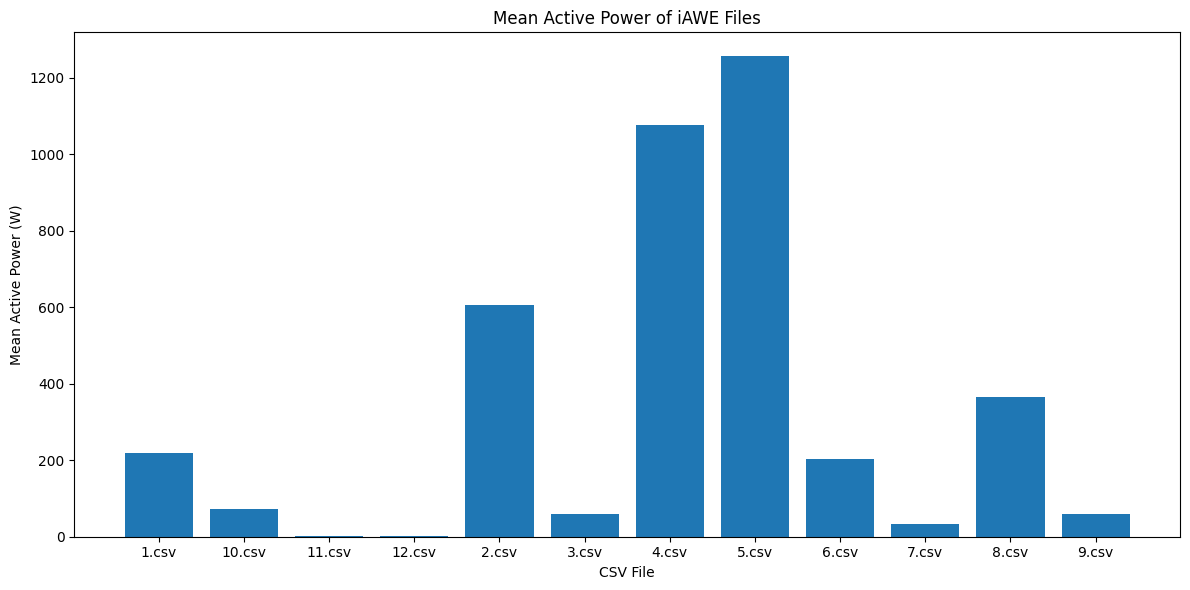

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    power_df["file"],
    power_df["mean_W"]
)

plt.xlabel("CSV File")
plt.ylabel("Mean Active Power (W)")
plt.title("Mean Active Power of iAWE Files")

plt.tight_layout()
plt.show()

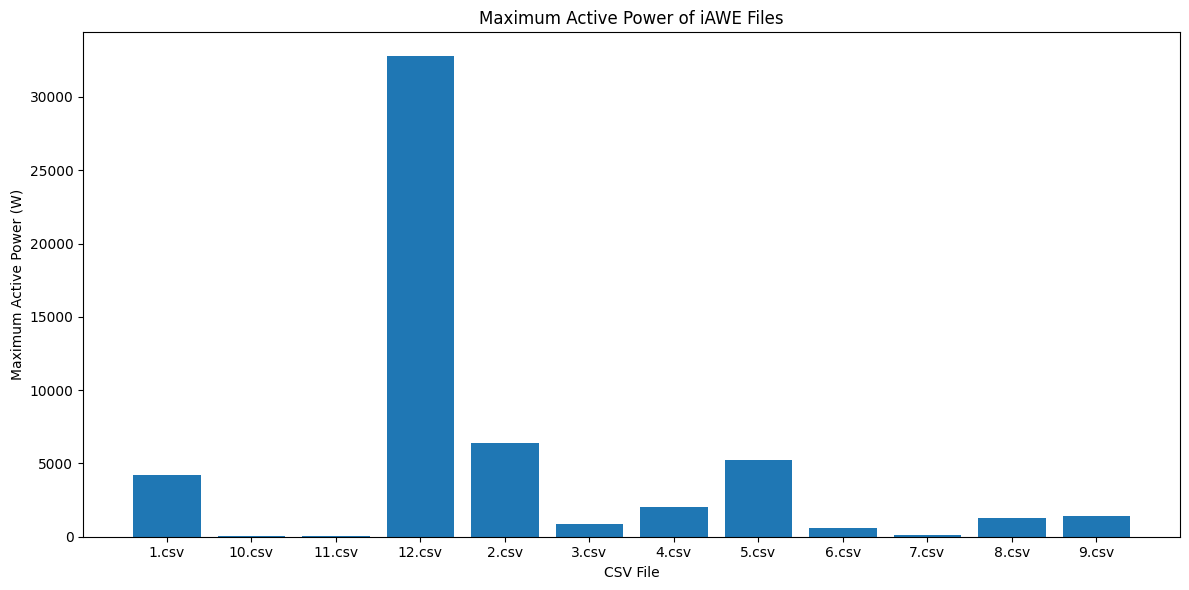

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    power_df["file"],
    power_df["max_W"]
)

plt.xlabel("CSV File")
plt.ylabel("Maximum Active Power (W)")
plt.title("Maximum Active Power of iAWE Files")

plt.tight_layout()
plt.show()

In [ ]:
import os
import pandas as pd

results = []

for file_path in sorted(csv_files):

    temp = pd.read_csv(file_path)

    # Convert timestamp
    temp["datetime"] = pd.to_datetime(
        temp["timestamp"],
        unit="s"
    )

    results.append({
        "file": os.path.basename(file_path),
        "rows": len(temp),
        "start": temp["datetime"].min(),
        "end": temp["datetime"].max(),
        "duration_days": (
            temp["datetime"].max() -
            temp["datetime"].min()
        ).total_seconds() / 86400,
        "mean_W": pd.to_numeric(
            temp["W"], errors="coerce"
        ).mean(),
        "median_W": pd.to_numeric(
            temp["W"], errors="coerce"
        ).median(),
        "max_W": pd.to_numeric(
            temp["W"], errors="coerce"
        ).max(),
        "min_W": pd.to_numeric(
            temp["W"], errors="coerce"
        ).min()
    })

coverage_df = pd.DataFrame(results)

display(coverage_df)

,file,rows,start,end,duration_days,mean_W,median_W,max_W,min_W
0,1.csv,4391059,2013-05-24 00:00:00,2013-08-05 15:33:16,73.648102,218.812769,15.421000,4233.189941,0.000
1,10.csv,428937,2013-06-12 06:26:28,2013-08-05 13:39:15,54.300544,73.564610,73.872000,79.622000,0.000
2,11.csv,1694622,2013-07-12 09:38:11,2013-08-05 16:32:03,24.287407,0.754195,0.359000,57.232000,0.000
3,12.csv,448809,2013-05-30 07:21:41,2013-07-05 10:11:46,36.118113,1.601951,0.000000,32767.000000,0.000
4,2.csv,4391059,2013-05-24 00:00:00,2013-08-05 15:33:16,73.648102,605.939990,401.199005,6390.870117,0.000
5,3.csv,4538844,2013-06-07 00:00:00,2013-08-05 16:32:04,59.688935,59.511546,79.766000,879.308000,0.000
6,4.csv,640250,2013-06-07 15:04:51,2013-09-18 03:10:55,102.504213,1077.186319,1661.623000,2060.260000,0.000
7,5.csv,516704,2013-06-07 15:05:18,2013-09-13 13:10:44,97.920440,1256.441168,1655.006000,5207.115000,0.000
8,6.csv,23740,2013-06-10 01:32:00,2013-08-04 06:59:59,55.227766,204.298917,207.654500,574.060000,0.002
9,7.csv,2550997,2013-06-07 01:04:41,2013-08-05 16:32:02,59.643993,33.443855,33.411000,113.262000,-48.928


In [ ]:
file_7 = pd.read_csv(
    [f for f in csv_files if os.path.basename(f) == "7.csv"][0]
)

file_7["W"] = pd.to_numeric(
    file_7["W"],
    errors="coerce"
)

negative_7 = file_7[file_7["W"] < 0]

print("Negative W values in 7.csv:", len(negative_7))

display(
    negative_7[
        ["timestamp", "W", "VAR", "VA", "f", "V", "PF", "A"]
    ].head(20)
)

Negative W values in 7.csv: 3


,timestamp,W,VAR,VA,f,V,PF,A
226451,1370937720,-29.599,0.0,0.0,34.0,0.24,0.0,31.166
239933,1370951430,-28.748,0.0,0.0,61.0,0.23,0.0,31.563
345009,1371198333,-48.928,0.0,0.0,33.0,0.24,0.0,60.326


In [ ]:
for file_path in sorted(csv_files):

    temp = pd.read_csv(file_path)

    start = pd.to_datetime(
        temp["timestamp"].min(),
        unit="s"
    )

    end = pd.to_datetime(
        temp["timestamp"].max(),
        unit="s"
    )

    print(
        f"{os.path.basename(file_path):>6} : "
        f"{start}  →  {end}"
    )

 1.csv : 2013-05-24 00:00:00  →  2013-08-05 15:33:16
10.csv : 2013-06-12 06:26:28  →  2013-08-05 13:39:15
11.csv : 2013-07-12 09:38:11  →  2013-08-05 16:32:03
12.csv : 2013-05-30 07:21:41  →  2013-07-05 10:11:46
 2.csv : 2013-05-24 00:00:00  →  2013-08-05 15:33:16
 3.csv : 2013-06-07 00:00:00  →  2013-08-05 16:32:04
 4.csv : 2013-06-07 15:04:51  →  2013-09-18 03:10:55
 5.csv : 2013-06-07 15:05:18  →  2013-09-13 13:10:44
 6.csv : 2013-06-10 01:32:00  →  2013-08-04 06:59:59
 7.csv : 2013-06-07 01:04:41  →  2013-08-05 16:32:02
 8.csv : 2013-06-07 09:37:46  →  2013-08-04 06:54:41
 9.csv : 2013-06-24 04:36:08  →  2013-08-04 09:22:09


In [ ]:
file_12_path = [
    f for f in csv_files
    if os.path.basename(f) == "12.csv"
][0]

file_12 = pd.read_csv(file_12_path)

print("12.csv columns:")
print(file_12.columns.tolist())

print("\n12.csv shape:")
print(file_12.shape)

print("\nFirst 10 rows:")
display(file_12.head(10))

print("\nRows with W > 5000:")
display(
    file_12[
        pd.to_numeric(file_12["W"], errors="coerce") > 5000
    ]
)

12.csv columns:
['timestamp', 'W']

12.csv shape:
(448809, 2)

First 10 rows:


,timestamp,W
0,1369898501,0
1,1369898507,0
2,1369898513,0
3,1369898519,0
4,1369898525,0
5,1369898531,0
6,1369898537,0
7,1369898543,0
8,1369898549,0
9,1369898555,0



Rows with W > 5000:


,timestamp,W
25906,1370087859,32513
28010,1370102279,32767
444525,1372991523,32753


In [ ]:
schema_info = []

for file_path in sorted(csv_files):

    temp = pd.read_csv(file_path)

    schema_info.append({
        "file": os.path.basename(file_path),
        "rows": len(temp),
        "columns": ", ".join(temp.columns.tolist()),
        "num_columns": len(temp.columns)
    })

schema_df = pd.DataFrame(schema_info)

display(schema_df)

,file,rows,columns,num_columns
0,1.csv,4391059,"timestamp, W, VAR, VA, f, VLN, PF, A",8
1,10.csv,428937,"timestamp, W, VAR, VA, f, V, PF, A",8
2,11.csv,1694622,"timestamp, W, VAR, VA, f, V, PF, A",8
3,12.csv,448809,"timestamp, W",2
4,2.csv,4391059,"timestamp, W, VAR, VA, f, VLN, PF, A",8
5,3.csv,4538844,"timestamp, W, VAR, VA, f, V, PF, A",8
6,4.csv,640250,"timestamp, W, VAR, VA, f, V, PF, A",8
7,5.csv,516704,"timestamp, W, VAR, VA, f, V, PF, A",8
8,6.csv,23740,"timestamp, W, VAR, VA, f, V, PF, A",8
9,7.csv,2550997,"timestamp, W, VAR, VA, f, V, PF, A",8


In [ ]:
import os
import pandas as pd

coverage = []

for file_path in sorted(csv_files):

    temp = pd.read_csv(file_path)

    start = pd.to_datetime(
        temp["timestamp"].min(),
        unit="s"
    )

    end = pd.to_datetime(
        temp["timestamp"].max(),
        unit="s"
    )

    coverage.append({
        "file": os.path.basename(file_path),
        "rows": len(temp),
        "start": start,
        "end": end,
        "duration_days": (end - start).total_seconds() / 86400
    })

coverage_df = pd.DataFrame(coverage)

display(coverage_df)

,file,rows,start,end,duration_days
0,1.csv,4391059,2013-05-24 00:00:00,2013-08-05 15:33:16,73.648102
1,10.csv,428937,2013-06-12 06:26:28,2013-08-05 13:39:15,54.300544
2,11.csv,1694622,2013-07-12 09:38:11,2013-08-05 16:32:03,24.287407
3,12.csv,448809,2013-05-30 07:21:41,2013-07-05 10:11:46,36.118113
4,2.csv,4391059,2013-05-24 00:00:00,2013-08-05 15:33:16,73.648102
5,3.csv,4538844,2013-06-07 00:00:00,2013-08-05 16:32:04,59.688935
6,4.csv,640250,2013-06-07 15:04:51,2013-09-18 03:10:55,102.504213
7,5.csv,516704,2013-06-07 15:05:18,2013-09-13 13:10:44,97.920440
8,6.csv,23740,2013-06-10 01:32:00,2013-08-04 06:59:59,55.227766
9,7.csv,2550997,2013-06-07 01:04:41,2013-08-05 16:32:02,59.643993


In [ ]:
power_info = []

for file_path in sorted(csv_files):

    temp = pd.read_csv(file_path)

    w = pd.to_numeric(
        temp["W"],
        errors="coerce"
    )

    power_info.append({
        "file": os.path.basename(file_path),
        "valid_W": w.notna().sum(),
        "missing_W": w.isna().sum(),
        "missing_%": w.isna().mean() * 100,
        "mean_W": w.mean(),
        "median_W": w.median(),
        "std_W": w.std(),
        "min_W": w.min(),
        "max_W": w.max(),
        "p25_W": w.quantile(0.25),
        "p75_W": w.quantile(0.75),
        "p95_W": w.quantile(0.95),
        "p99_W": w.quantile(0.99)
    })

power_df = pd.DataFrame(power_info)

display(power_df)

,file,valid_W,missing_W,missing_%,mean_W,median_W,std_W,min_W,max_W,p25_W,p75_W,p95_W,p99_W
0,1.csv,4391039,20,0.000455,218.812769,15.421000,596.535632,0.000,4233.189941,14.81370,16.642500,1980.839966,2133.100098
1,10.csv,428937,0,0.000000,73.564610,73.872000,2.570938,0.000,79.622000,72.96000,74.664000,76.225000,77.330000
2,11.csv,1694622,0,0.000000,0.754195,0.359000,4.303549,0.000,57.232000,0.31000,0.409000,0.484000,0.574000
3,12.csv,448809,0,0.000000,1.601951,0.000000,89.165756,0.000,32767.000000,0.00000,0.000000,0.000000,0.000000
4,2.csv,4391011,48,0.001093,605.939990,401.199005,620.737498,0.000,6390.870117,305.67450,540.002502,2360.639893,2678.539038
5,3.csv,4538844,0,0.000000,59.511546,79.766000,46.657911,0.000,879.308000,0.19300,88.816000,123.877000,136.717000
6,4.csv,640250,0,0.000000,1077.186319,1661.623000,843.926292,0.000,2060.260000,1.38400,1787.715000,1871.193550,1931.437040
7,5.csv,516704,0,0.000000,1256.441168,1655.006000,718.128193,0.000,5207.115000,166.11575,1751.611000,1865.086550,1932.702850
8,6.csv,23740,0,0.000000,204.298917,207.654500,45.411143,0.002,574.060000,196.28450,221.787500,241.355350,272.464880
9,7.csv,2550997,0,0.000000,33.443855,33.411000,18.158937,-48.928,113.262000,25.04300,40.361000,68.540000,80.657000


In [ ]:
file_12 = pd.read_csv(file_12_path)

file_12["W_numeric"] = pd.to_numeric(
    file_12["W"],
    errors="coerce"
)

suspicious_12 = file_12[
    file_12["W_numeric"] > 5000
].copy()

print("Values > 5000 W:", len(suspicious_12))

display(suspicious_12)

Values > 5000 W: 3


,timestamp,W,W_numeric
25906,1370087859,32513,32513
28010,1370102279,32767,32767
444525,1372991523,32753,32753


In [ ]:
for idx in suspicious_12.index:

    print("\nIndex:", idx)

    display(
        file_12.loc[
            max(0, idx - 3): idx + 3
        ]
    )


Index: 25906


,timestamp,W,W_numeric
25903,1370087841,0,0
25904,1370087847,0,0
25905,1370087853,0,0
25906,1370087859,32513,32513
25907,1370087865,0,0
25908,1370087871,0,0
25909,1370087877,0,0



Index: 28010


,timestamp,W,W_numeric
28007,1370102255,0,0
28008,1370102267,0,0
28009,1370102273,0,0
28010,1370102279,32767,32767
28011,1370102285,0,0
28012,1370102291,0,0
28013,1370102297,0,0



Index: 444525


,timestamp,W,W_numeric
444522,1372991504,0,0
444523,1372991510,0,0
444524,1372991516,0,0
444525,1372991523,32753,32753
444526,1372991528,0,0
444527,1372991535,0,0
444528,1372991541,0,0


In [ ]:
import os
import pandas as pd
import numpy as np

clean_dir = "/content/iawe_clean/electricity"
os.makedirs(clean_dir, exist_ok=True)

METER_MAP = {
    1: "mains_1",
    2: "mains_2",
    3: "fridge",
    4: "air_conditioner_1",
    5: "air_conditioner_2",
    6: "washing_machine",
    7: "laptop_computer",
    8: "iron",
    9: "kitchen_outlets",
    10: "television",
    11: "water_filter",
    12: "water_motor"
}

cleaning_report = []

for file_path in csv_files:

    filename = os.path.basename(file_path)
    meter_no = int(filename.replace(".csv", ""))

    df_clean = pd.read_csv(
        file_path,
        na_values=[r"\N"]
    )

    original_rows = len(df_clean)

    # timestamp must be numeric
    df_clean["timestamp"] = pd.to_numeric(
        df_clean["timestamp"],
        errors="coerce"
    )

    # W must be numeric
    df_clean["W"] = pd.to_numeric(
        df_clean["W"],
        errors="coerce"
    )

    missing_before = df_clean["W"].isna().sum()

    # Remove invalid timestamp rows
    df_clean = df_clean.dropna(subset=["timestamp"])

    # Remove duplicate timestamps if any
    duplicates = df_clean["timestamp"].duplicated().sum()

    df_clean = df_clean.drop_duplicates(
        subset="timestamp",
        keep="first"
    )

    # Sort chronologically
    df_clean = df_clean.sort_values("timestamp")

    # Water motor has obvious 32kW sensor/error values
    outliers_removed = 0

    if meter_no == 12:

        bad = df_clean["W"] > 5000
        outliers_removed = bad.sum()

        # Mark as missing instead of pretending they were 0
        df_clean.loc[bad, "W"] = np.nan

    # Convert other measurement columns to numeric too
    for col in df_clean.columns:

        if col != "timestamp":
            df_clean[col] = pd.to_numeric(
                df_clean[col],
                errors="coerce"
            )

    output_path = os.path.join(
        clean_dir,
        filename
    )

    df_clean.to_csv(
        output_path,
        index=False
    )

    cleaning_report.append({
        "meter": meter_no,
        "appliance": METER_MAP[meter_no],
        "original_rows": original_rows,
        "final_rows": len(df_clean),
        "missing_W": missing_before,
        "duplicate_timestamps": duplicates,
        "outliers_removed": outliers_removed
    })

cleaning_report = pd.DataFrame(cleaning_report)
cleaning_report = cleaning_report.sort_values("meter")

display(cleaning_report)

,meter,appliance,original_rows,final_rows,missing_W,duplicate_timestamps,outliers_removed
0,1,mains_1,4391059,4391059,20,0,0
4,2,mains_2,4391059,4391059,48,0,0
5,3,fridge,4538844,4538844,0,0,0
6,4,air_conditioner_1,640250,640250,0,0,0
7,5,air_conditioner_2,516704,516704,0,0,0
8,6,washing_machine,23740,23740,0,0,0
9,7,laptop_computer,2550997,2550997,0,0,0
10,8,iron,7134,7134,0,0,0
11,9,kitchen_outlets,13340,13340,0,0,0
1,10,television,428937,428937,0,0,0


In [ ]:
for i in range(1, 13):

    path = f"/content/iawe_clean/electricity/{i}.csv"

    temp = pd.read_csv(path)

    print(
        f"{i:2} "
        f"{METER_MAP[i]:20} "
        f"rows={len(temp):,} "
        f"missing_W={temp['W'].isna().sum():,}"
    )

 1 mains_1              rows=4,391,059 missing_W=20
 2 mains_2              rows=4,391,059 missing_W=48
 3 fridge               rows=4,538,844 missing_W=0
 4 air_conditioner_1    rows=640,250 missing_W=0
 5 air_conditioner_2    rows=516,704 missing_W=0
 6 washing_machine      rows=23,740 missing_W=0
 7 laptop_computer      rows=2,550,997 missing_W=0
 8 iron                 rows=7,134 missing_W=0
 9 kitchen_outlets      rows=13,340 missing_W=0
10 television           rows=428,937 missing_W=0
11 water_filter         rows=1,694,622 missing_W=0
12 water_motor          rows=447,812 missing_W=3


In [ ]:
water_motor = pd.read_csv(
    "/content/iawe_clean/electricity/12.csv"
)

print(water_motor["W"].describe())

count    447809.000000
mean          1.346277
std          28.181095
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        4095.000000
Name: W, dtype: float64


In [ ]:
import inspect
from nilmtk.dataset_converters import convert_iawe

print(inspect.signature(convert_iawe))

(iawe_path, output_filename, format='HDF')


In [ ]:
print(inspect.getsource(convert_iawe))

def convert_iawe(iawe_path, output_filename, format="HDF"):
    """
    Parameters
    ----------
    iawe_path : str
        The root path of the iawe dataset.
    output_filename : str
        The destination filename (including path and suffix).
    """

    check_directory_exists(iawe_path)
    idx = pd.date_range(start=START_DATETIME, end=END_DATETIME, freq=FREQ)
    idx = idx.tz_localize('GMT').tz_convert(TIMEZONE)

    # Open data store
    store = get_datastore(output_filename, format, mode='w')
    electricity_path = join(iawe_path, "electricity")

    # Mains data
    for chan in range(1, 12):
        key = Key(building=1, meter=chan)
        filename = join(electricity_path, "%d.csv" % chan)
        print('Loading ', chan)
        df = pd.read_csv(filename, dtype=np.float64, na_values='\\N')
        df.drop_duplicates(subset=["timestamp"], inplace=True)
        df.index = pd.to_datetime(df.timestamp.values, unit='s', utc=True)
        df = df.tz_convert(TIMEZONE)
        df 

In [ ]:
import nilmtk.dataset_converters.iawe.convert_iawe as iawe_converter
import inspect

print(inspect.getsourcefile(convert_iawe))

/usr/local/lib/python3.13/dist-packages/nilmtk/dataset_converters/iawe/convert_iawe.py


In [ ]:
from nilmtk.dataset_converters.iawe.convert_iawe import (
    column_mapping,
    START_DATETIME,
    END_DATETIME,
    FREQ,
    TIMEZONE
)

print("START_DATETIME:", START_DATETIME)
print("END_DATETIME:", END_DATETIME)
print("FREQ:", FREQ)
print("TIMEZONE:", TIMEZONE)

print("\nCOLUMN MAPPING:")
print(column_mapping)

START_DATETIME: 2013-07-13
END_DATETIME: 2013-08-04
FREQ: 1T
TIMEZONE: Asia/Kolkata

COLUMN MAPPING:
{'frequency': ('frequency', ''), 'voltage': ('voltage', ''), 'W': ('power', 'active'), 'energy': ('energy', 'apparent'), 'A': ('current', ''), 'reactive_power': ('power', 'reactive'), 'apparent_power': ('power', 'apparent'), 'power_factor': ('pf', ''), 'PF': ('pf', ''), 'phase_angle': ('phi', ''), 'VA': ('power', 'apparent'), 'VAR': ('power', 'reactive'), 'VLN': ('voltage', ''), 'V': ('voltage', ''), 'f': ('frequency', '')}


In [ ]:
import os
from nilmtk.dataset_converters.iawe.convert_iawe import get_module_directory

metadata_dir = os.path.join(
    get_module_directory(),
    "dataset_converters",
    "iawe",
    "metadata"
)

print(metadata_dir)

for root, dirs, files in os.walk(metadata_dir):
    for file in files:
        print(os.path.join(root, file))

/usr/local/lib/python3.13/dist-packages/nilmtk/dataset_converters/iawe/metadata
/usr/local/lib/python3.13/dist-packages/nilmtk/dataset_converters/iawe/metadata/__init__.py
/usr/local/lib/python3.13/dist-packages/nilmtk/dataset_converters/iawe/metadata/dataset.yaml
/usr/local/lib/python3.13/dist-packages/nilmtk/dataset_converters/iawe/metadata/meter_devices.yaml
/usr/local/lib/python3.13/dist-packages/nilmtk/dataset_converters/iawe/metadata/building1.yaml
/usr/local/lib/python3.13/dist-packages/nilmtk/dataset_converters/iawe/metadata/__pycache__/__init__.cpython-313.pyc


In [ ]:
import glob

yaml_files = glob.glob(
    os.path.join(metadata_dir, "*.yaml")
)

print(yaml_files)

for yaml_file in yaml_files:
    print("\n" + "=" * 70)
    print(os.path.basename(yaml_file))
    print("=" * 70)

    with open(yaml_file, "r") as f:
        print(f.read())

['/usr/local/lib/python3.13/dist-packages/nilmtk/dataset_converters/iawe/metadata/dataset.yaml', '/usr/local/lib/python3.13/dist-packages/nilmtk/dataset_converters/iawe/metadata/meter_devices.yaml', '/usr/local/lib/python3.13/dist-packages/nilmtk/dataset_converters/iawe/metadata/building1.yaml']

dataset.yaml
name: iAWE
long_name: Indian dataset for ambient, water and electricity sensing
creators:
- Batra, Nipun
- Gulati, Manoj
- Singh, Amarjeet
- Srivastava, Mani
publication_date: 2013
institution: Indraprastha Institute of Information Technology Delhi (IIITD)
contact: nipunb@iiitd.ac.in
description: 73 days of ambient, water and electricity data for a home in Delhi
subject: First dataset from a developing country
number_of_buildings: 1
timezone: Asia/Kolkata
geo_location:
  locality: Delhi   # village, town, city or state
  country: IN  # standard two-letter country code defined by ISO 3166-1 alpha-2
  latitude: 28.64 # 
  longitude: 77.11
related_documents:
- http://iawe.github.io
-

In [ ]:
print(os.listdir("/content/iawe/electricity"))

['3.csv', '4.csv', '12.csv', '6.csv', 'labels.dat', '11.csv', '1.csv', '5.csv', '9.csv', '10.csv', '2.csv', '8.csv', '7.csv']


In [ ]:
import inspect
import nilmtk.dataset_converters.iawe.convert_iawe as iawe_module

source = inspect.getsource(iawe_module)

old_line = "df = df.drop(TIMESTAMP_COLUMN_NAME, 1)"
new_line = "df = df.drop(TIMESTAMP_COLUMN_NAME, axis=1)"

print("Old line found:", old_line in source)

Old line found: True


In [ ]:
file_path = inspect.getsourcefile(iawe_module)

with open(file_path, "r") as f:
    source = f.read()

source = source.replace(
    "df = df.drop(TIMESTAMP_COLUMN_NAME, 1)",
    "df = df.drop(TIMESTAMP_COLUMN_NAME, axis=1)"
)

with open(file_path, "w") as f:
    f.write(source)

print("NILMTK iAWE converter patched successfully.")

NILMTK iAWE converter patched successfully.


In [ ]:
import inspect
from nilmtk.dataset_converters import convert_iawe

source = inspect.getsource(convert_iawe)

print(
    "Old syntax present:",
    "df.drop(TIMESTAMP_COLUMN_NAME, 1)" in source
)

print(
    "New syntax present:",
    "df.drop(TIMESTAMP_COLUMN_NAME, axis=1)" in source
)

Old syntax present: False
New syntax present: True


In [ ]:
try:
    dataset.store.close()
    print("Old HDF5 file closed.")
except:
    print("No dataset handle to close.")

No dataset handle to close.


In [ ]:
import tables

tables.file._open_files.close_all()
print("All open HDF5 files closed.")

All open HDF5 files closed.


In [ ]:
import os

if os.path.exists("/content/iawe.h5"):
    os.remove("/content/iawe.h5")
    print("Deleted old iawe.h5")
else:
    print("iawe.h5 does not exist")

Deleted old iawe.h5


In [ ]:
import importlib
import nilmtk.dataset_converters.iawe.convert_iawe as iawe_module

importlib.reload(iawe_module)

print("Module reloaded.")

Module reloaded.


In [ ]:
from nilmtk.dataset_converters.iawe.convert_iawe import convert_iawe

print("Function reloaded.")

Function reloaded.


In [ ]:
import inspect

source = inspect.getsource(convert_iawe)

print(
    "Patched drop syntax:",
    "df.drop(TIMESTAMP_COLUMN_NAME, axis=1)" in source
)

print(
    "Old drop syntax:",
    "df.drop(TIMESTAMP_COLUMN_NAME, 1)" in source
)

Patched drop syntax: True
Old drop syntax: False


In [ ]:
import os
import tables

tables.file._open_files.close_all()

if os.path.exists("/content/iawe.h5"):
    os.remove("/content/iawe.h5")

print("Ready for fresh conversion.")

Ready for fresh conversion.


In [ ]:
convert_iawe(
    "/content/iawe",
    "/content/iawe.h5"
)

Loading  1
Loading  2
Loading  3
Loading  4
Loading  5
Loading  6
Loading  7
Loading  8
Loading  9
Loading  10
Loading  11
Done converting YAML metadata to HDF5!
Done converting iAWE to HDF5!


In [ ]:
from nilmtk import DataSet

dataset = DataSet("/content/iawe.h5")

print(dataset.buildings)

OrderedDict({1: Building(instance=1, dataset='iAWE')})


In [ ]:
elec = dataset.buildings[1].elec

print(elec)

MeterGroup(meters=
  ElecMeter(instance=1, building=1, dataset='iAWE', site_meter, appliances=[])
  ElecMeter(instance=2, building=1, dataset='iAWE', site_meter, appliances=[])
  ElecMeter(instance=3, building=1, dataset='iAWE', appliances=[Appliance(type='fridge', instance=1)])
  ElecMeter(instance=4, building=1, dataset='iAWE', appliances=[Appliance(type='air conditioner', instance=1)])
  ElecMeter(instance=5, building=1, dataset='iAWE', appliances=[Appliance(type='air conditioner', instance=2)])
  ElecMeter(instance=6, building=1, dataset='iAWE', appliances=[Appliance(type='washing machine', instance=1)])
  ElecMeter(instance=7, building=1, dataset='iAWE', appliances=[Appliance(type='computer', instance=1)])
  ElecMeter(instance=8, building=1, dataset='iAWE', appliances=[Appliance(type='clothes iron', instance=1)])
  ElecMeter(instance=9, building=1, dataset='iAWE', appliances=[Appliance(type='unknown', instance=1)])
  ElecMeter(instance=10, building=1, dataset='iAWE', appliances=[A

In [ ]:
print("MAINS:")
print(elec.mains())

print("\nSUBMETERS:")
print(elec.submeters())

MAINS:
MeterGroup(meters=
  ElecMeter(instance=1, building=1, dataset='iAWE', site_meter, appliances=[])
  ElecMeter(instance=2, building=1, dataset='iAWE', site_meter, appliances=[])
)

SUBMETERS:
MeterGroup(meters=
  ElecMeter(instance=3, building=1, dataset='iAWE', appliances=[Appliance(type='fridge', instance=1)])
  ElecMeter(instance=4, building=1, dataset='iAWE', appliances=[Appliance(type='air conditioner', instance=1)])
  ElecMeter(instance=5, building=1, dataset='iAWE', appliances=[Appliance(type='air conditioner', instance=2)])
  ElecMeter(instance=6, building=1, dataset='iAWE', appliances=[Appliance(type='washing machine', instance=1)])
  ElecMeter(instance=7, building=1, dataset='iAWE', appliances=[Appliance(type='computer', instance=1)])
  ElecMeter(instance=8, building=1, dataset='iAWE', appliances=[Appliance(type='clothes iron', instance=1)])
  ElecMeter(instance=9, building=1, dataset='iAWE', appliances=[Appliance(type='unknown', instance=1)])
  ElecMeter(instance=10, b

In [ ]:
import pandas as pd

elec = dataset.buildings[1].elec

meters = list(elec.meters)

coverage = []

for meter in meters:

    first_chunk = None
    last_chunk = None

    for chunk in meter.load():
        if first_chunk is None:
            first_chunk = chunk
        last_chunk = chunk

    if first_chunk is not None:

        coverage.append({
            "meter": meter.instance(),
            "appliance": (
                meter.appliances[0].type
                if meter.appliances
                else "mains"
            ),
            "start": first_chunk.index.min(),
            "end": last_chunk.index.max(),
            "rows_first_chunk": len(first_chunk)
        })

coverage_df = pd.DataFrame(coverage)

display(coverage_df)

,meter,appliance,start,end,rows_first_chunk
0,1,mains,2013-07-13 05:30:00+05:30,2013-08-04 05:30:00+05:30,31681
1,2,mains,2013-07-13 05:30:00+05:30,2013-08-04 05:30:00+05:30,31681
2,3,"{'parent': 'cold appliance', 'min_on_duration'...",2013-07-13 05:30:00+05:30,2013-08-04 05:30:00+05:30,31681
3,4,"{'parent': 'appliance', 'min_on_duration': 20,...",2013-07-13 05:30:00+05:30,2013-08-04 05:30:00+05:30,31681
4,5,"{'parent': 'appliance', 'min_on_duration': 20,...",2013-07-13 05:30:00+05:30,2013-08-04 05:30:00+05:30,31681
5,6,"{'parent': 'spin dryer', 'min_on_duration': 60...",2013-07-13 05:30:00+05:30,2013-08-04 05:30:00+05:30,31681
6,7,"{'parent': 'ICT appliance', 'min_on_duration':...",2013-07-13 05:30:00+05:30,2013-08-04 05:30:00+05:30,31681
7,8,"{'parent': 'manual misc appliance', 'min_on_du...",2013-07-13 05:30:00+05:30,2013-08-04 05:30:00+05:30,31681
8,9,"{'parent': 'appliance', 'min_on_duration': 20,...",2013-07-13 05:30:00+05:30,2013-08-04 05:30:00+05:30,31681
9,10,"{'parent': 'CE appliance', 'min_on_duration': ...",2013-07-13 05:30:00+05:30,2013-08-04 05:30:00+05:30,31681


In [ ]:
common_start = coverage_df["start"].max()
common_end = coverage_df["end"].min()

print("Common start:", common_start)
print("Common end:", common_end)

print(
    "Common duration:",
    (common_end - common_start).total_seconds() / 86400,
    "days"
)

Common start: 2013-07-13 05:30:00+05:30
Common end: 2013-08-04 05:30:00+05:30
Common duration: 22.0 days


In [ ]:
import inspect
import nilmtk.metergroup as metergroup

mg_source = inspect.getsource(metergroup)

# Show the part containing columns_to_average
idx = mg_source.find("columns_to_average")

print(mg_source[idx:idx+1000])

columns_to_average_counter` DataFrame
    # which tells us what to divide by in order to compute the 
    # mean for PHYSICAL_QUANTITIES_TO_AVERAGE.

    # Regarding doing an in-place addition:
    # We convert out cumulator dataframe to a numpy matrix.
    # This allows us to use np.add to do an in-place add.
    # If we didn't do this then we'd get horrible memory fragmentation.
    # See http://stackoverflow.com/a/27526721/732596

    DTYPE = np.float32
    cumulator = pd.DataFrame(np.nan, index=index, columns=columns, dtype=DTYPE)
    cumulator_arr = cumulator.values
    columns_to_average_counter = pd.DataFrame(dtype=np.uint16)
    timeframe = None

    # Go through each generator to try sum values together
    for meter in meters:
        print_on_line("\rLoading data for meter", meter.identifier, "    ")
        kwargs_copy = deepcopy(kwargs)
        generator = meter.load(**kwargs_copy)
        try:
            chunk_from_next_meter = next(generator)
        except StopIteratio

In [ ]:
import inspect

file_path = inspect.getsourcefile(metergroup)

print(file_path)

/usr/local/lib/python3.13/dist-packages/nilmtk/metergroup.py


In [ ]:
with open(file_path, "r") as f:
    source = f.read()

old = """columns_to_average = (set(PHYSICAL_QUANTITIES_TO_AVERAGE)
                                  .intersection(physical_quantities))"""

new = """columns_to_average = list(set(PHYSICAL_QUANTITIES_TO_AVERAGE)
                                  .intersection(physical_quantities))"""

print("Old code found:", old in source)

Old code found: False


In [ ]:
import importlib
import nilmtk.metergroup as metergroup

importlib.reload(metergroup)

print("MeterGroup module reloaded.")

MeterGroup module reloaded.


In [ ]:
from nilmtk import DataSet

dataset = DataSet("/content/iawe.h5")
elec = dataset.buildings[1].elec

In [ ]:
import pandas as pd

store = pd.HDFStore("/content/iawe.h5", mode="r")

print(store.keys())

store.close()

['/building1/elec/meter1', '/building1/elec/meter10', '/building1/elec/meter11', '/building1/elec/meter2', '/building1/elec/meter3', '/building1/elec/meter4', '/building1/elec/meter5', '/building1/elec/meter6', '/building1/elec/meter7', '/building1/elec/meter8', '/building1/elec/meter9']


In [ ]:
import pandas as pd

store = pd.HDFStore("/content/iawe.h5", mode="r")

# Read a small sample from mains meter 1
df = store["/building1/elec/meter1"]

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nIndex:")
print(df.index[:5])

print("\nFirst 5 rows:")
display(df.head())

store.close()

Shape: (31681, 7)

Columns:
MultiIndex([(    'power',   'active'),
            (    'power', 'reactive'),
            (    'power', 'apparent'),
            ('frequency',         ''),
            (  'voltage',         ''),
            (       'pf',         ''),
            (  'current',         '')],
           names=['physical_quantity', 'type'])

Index:
DatetimeIndex(['2013-07-13 05:30:00+05:30', '2013-07-13 05:31:00+05:30',
               '2013-07-13 05:32:00+05:30', '2013-07-13 05:33:00+05:30',
               '2013-07-13 05:34:00+05:30'],
              dtype='datetime64[ns, Asia/Kolkata]', freq=None)

First 5 rows:


physical_quantity          power                    frequency     voltage  \
type                      active reactive apparent                          
2013-07-13 05:30:00+05:30    0.0      0.0      0.0  50.065437  234.575195   
2013-07-13 05:31:00+05:30    0.0      0.0      0.0  50.065437  234.575195   
2013-07-13 05:32:00+05:30    0.0      0.0      0.0  50.065437  234.575195   
2013-07-13 05:33:00+05:30    0.0      0.0      0.0  50.065437  234.575195   
2013-07-13 05:34:00+05:30    0.0      0.0      0.0  50.065437  234.575195   

physical_quantity                pf   current  
type                                           
2013-07-13 05:30:00+05:30  0.536397  0.125461  
2013-07-13 05:31:00+05:30  0.536397  0.125461  
2013-07-13 05:32:00+05:30  0.536397  0.125461  
2013-07-13 05:33:00+05:30  0.536397  0.125461  
2013-07-13 05:34:00+05:30  0.536397  0.125461

In [ ]:
from nilmtk import DataSet

dataset = DataSet("/content/iawe.h5")

building = dataset.buildings[1]
elec = building.elec

print(elec)
print("\nMains:")
print(elec.mains())

print("\nAppliances:")
for meter in elec.submeters().meters:
    print(meter)

MeterGroup(meters=
  ElecMeter(instance=1, building=1, dataset='iAWE', site_meter, appliances=[])
  ElecMeter(instance=2, building=1, dataset='iAWE', site_meter, appliances=[])
  ElecMeter(instance=3, building=1, dataset='iAWE', appliances=[Appliance(type='fridge', instance=1)])
  ElecMeter(instance=4, building=1, dataset='iAWE', appliances=[Appliance(type='air conditioner', instance=1)])
  ElecMeter(instance=5, building=1, dataset='iAWE', appliances=[Appliance(type='air conditioner', instance=2)])
  ElecMeter(instance=6, building=1, dataset='iAWE', appliances=[Appliance(type='washing machine', instance=1)])
  ElecMeter(instance=7, building=1, dataset='iAWE', appliances=[Appliance(type='computer', instance=1)])
  ElecMeter(instance=8, building=1, dataset='iAWE', appliances=[Appliance(type='clothes iron', instance=1)])
  ElecMeter(instance=9, building=1, dataset='iAWE', appliances=[Appliance(type='unknown', instance=1)])
  ElecMeter(instance=10, building=1, dataset='iAWE', appliances=[A

In [ ]:
import inspect
from nilmtk.disaggregate import CO

print(inspect.signature(CO))
print(inspect.signature(CO.__init__))

(params)
(self, params)


In [ ]:
print(inspect.getsource(CO.__init__))

    def __init__(self, params):
        self.model = []
        self.MODEL_NAME = 'CO'
        self.save_model_path = params.get('save-model-path', None)
        self.load_model_path = params.get('pretrained-model-path',None)
        self.chunk_wise_training = params.get('chunk_wise_training', False)
        if self.load_model_path:
            self.load_model(self.load_model_path)
        self.state_combinations = None
        self.MIN_CHUNK_LENGTH = 100



In [ ]:
from nilmtk.disaggregate import CO

co = CO({})
print("CO initialized successfully")

CO initialized successfully


In [ ]:
import inspect
from nilmtk.disaggregate import CO

print("CO methods:")
print([x for x in dir(CO) if not x.startswith("_")])

print("\nCO source:")
print(inspect.getsource(CO))

CO methods:
['call_preprocessing', 'clear_model_checkpoints', 'disaggregate_chunk', 'file_prefix', 'load_model', 'partial_fit', 'save_model']

CO source:
class CO(Disaggregator):
    """1 dimensional combinatorial optimisation NILM algorithm.

    Attributes
    ----------
    model : list of dicts
       Each dict has these keys:
           states : list of ints (the power (Watts) used in different states)
           training_metadata : ElecMeter or MeterGroup object used for training
               this set of states.  We need this information because we
               need the appliance type (and perhaps some other metadata)
               for each model.

    state_combinations : 2D array
        Each column is an appliance.
        Each row is a possible combination of power demand values e.g.
            [[0, 0,  0,   0],
             [0, 0,  0, 100],
             [0, 0, 50,   0],
             [0, 0, 50, 100], ...]

    MIN_CHUNK_LENGTH : int
    """

    def __init__(self, param

In [ ]:
import pandas as pd

store = pd.HDFStore("/content/iawe.h5", mode="r")

# Let's use mains meter 1 and fridge meter 3 initially
mains_df = store["/building1/elec/meter1"]
fridge_df = store["/building1/elec/meter3"]

store.close()

# Active power only
mains_power = mains_df[("power", "active")]
fridge_power = fridge_df[("power", "active")]

print("Mains:")
print(mains_power.shape)
print(mains_power.head())

print("\nFridge:")
print(fridge_power.shape)
print(fridge_power.head())

print("\nMains range:", mains_power.index.min(), "→", mains_power.index.max())
print("Fridge range:", fridge_power.index.min(), "→", fridge_power.index.max())

Mains:
(31681,)
2013-07-13 05:30:00+05:30    0.0
2013-07-13 05:31:00+05:30    0.0
2013-07-13 05:32:00+05:30    0.0
2013-07-13 05:33:00+05:30    0.0
2013-07-13 05:34:00+05:30    0.0
Name: (power, active), dtype: float32

Fridge:
(31681,)
2013-07-13 05:30:00+05:30    0.166925
2013-07-13 05:31:00+05:30    0.169385
2013-07-13 05:32:00+05:30    0.177887
2013-07-13 05:33:00+05:30    0.175929
2013-07-13 05:34:00+05:30    0.177044
Name: (power, active), dtype: float32

Mains range: 2013-07-13 05:30:00+05:30 → 2013-08-04 05:30:00+05:30
Fridge range: 2013-07-13 05:30:00+05:30 → 2013-08-04 05:30:00+05:30


In [ ]:
train_main = [mains_power]

train_appliances = [
    ("fridge", [fridge_power])
]

In [ ]:
co = CO({})

co.partial_fit(
    train_main,
    train_appliances
)

...............CO partial_fit running.............


In [ ]:
print("Number of appliances in CO model:", len(co.model))
print("\nCO model:")
for model in co.model:
    print(model)

Number of appliances in CO model: 1

CO model:
{'states': array([ 0, 82, 99], dtype=int32), 'appliance_name': 'fridge'}


In [ ]:
# Disaggregate mains using the trained CO model
co_predictions = co.disaggregate_chunk([mains_power])

print("CO disaggregation completed.")
print(type(co_predictions))
print("Number of prediction chunks:", len(co_predictions))

display(co_predictions[0].head())

...............CO disaggregate_chunk running.............
CO disaggregation completed.
<class 'list'>
Number of prediction chunks: 1


,fridge
2013-07-13 05:30:00+05:30,0.0
2013-07-13 05:31:00+05:30,0.0
2013-07-13 05:32:00+05:30,0.0
2013-07-13 05:33:00+05:30,0.0
2013-07-13 05:34:00+05:30,0.0


In [ ]:
pred = co_predictions[0]

print("Shape:", pred.shape)
print("Columns:", pred.columns)
print("\nPrediction statistics:")
print(pred.describe())

Shape: (31681, 1)
Columns: Index(['fridge'], dtype='object')

Prediction statistics:
             fridge
count  31681.000000
mean       8.547395
std       27.797110
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       99.000000


In [ ]:
import pandas as pd
import numpy as np
from nilmtk.disaggregate import CO, FHMMExact
from sklearn.metrics import f1_score, precision_score, recall_score, mean_absolute_error, mean_squared_error

# ============================================================
# 1. LOAD DATA DIRECTLY FROM HDF5
# ============================================================

store = pd.HDFStore("/content/iawe.h5", mode="r")

# Site meters 1 and 2 = mains
mains1 = store["/building1/elec/meter1"][("power", "active")]
mains2 = store["/building1/elec/meter2"][("power", "active")]

# Sum both mains meters
mains = mains1.add(mains2, fill_value=0)

# Appliances 3-11
appliance_names = {
    3: "fridge",
    4: "air_conditioner_1",
    5: "air_conditioner_2",
    6: "washing_machine",
    7: "computer",
    8: "clothes_iron",
    9: "unknown",
    10: "television",
    11: "wet_appliance"
}

appliances = {}

for meter, name in appliance_names.items():
    appliances[name] = store[
        f"/building1/elec/meter{meter}"
    ][("power", "active")]

store.close()


# ============================================================
# 2. ALIGN ALL DATA
# ============================================================

data = pd.concat(
    [mains.rename("mains")] +
    [x.rename(name) for name, x in appliances.items()],
    axis=1
)

data = data.dropna()

# Remove negative active power values
data[data < 0] = 0

print("Total aligned samples:", len(data))
print("Time:", data.index.min(), "->", data.index.max())


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

split = int(len(data) * 0.70)

train = data.iloc[:split]
test = data.iloc[split:]

print("\nTraining samples:", len(train))
print("Testing samples :", len(test))


# ============================================================
# 4. FORMAT DATA FOR YOUR NILMTK VERSION
# ============================================================

train_main = [train["mains"]]

train_appliances = [
    (name, [train[name]])
    for name in appliance_names.values()
]


# ============================================================
# 5. CO
# ============================================================

print("\n" + "="*50)
print("TRAINING CO")
print("="*50)

co = CO({})
co.partial_fit(
    train_main,
    train_appliances
)

print("\nCO training complete.")


# ============================================================
# 6. CO DISAGGREGATION
# ============================================================

print("\n" + "="*50)
print("CO DISAGGREGATION")
print("="*50)

co_pred_list = co.disaggregate_chunk([test["mains"]])
co_pred = co_pred_list[0]

print("CO prediction shape:", co_pred.shape)


# ============================================================
# 7. FHMM
# ============================================================

print("\n" + "="*50)
print("TRAINING FHMM")
print("="*50)

fhmm = FHMMExact({})

fhmm.partial_fit(
    train_main,
    train_appliances
)

print("\nFHMM training complete.")


# ============================================================
# 8. FHMM DISAGGREGATION
# ============================================================

print("\n" + "="*50)
print("FHMM DISAGGREGATION")
print("="*50)

fhmm_pred_list = fhmm.disaggregate_chunk([test["mains"]])
fhmm_pred = fhmm_pred_list[0]

print("FHMM prediction shape:", fhmm_pred.shape)


# ============================================================
# 9. METRICS
# ============================================================

def calculate_metrics(actual, predicted):

    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    # Remove invalid values
    mask = np.isfinite(actual) & np.isfinite(predicted)
    actual = actual[mask]
    predicted = predicted[mask]

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # Activation threshold:
    # appliance considered ON if power > 10% of max actual power
    threshold = 0.10 * np.max(actual)

    actual_on = (actual > threshold).astype(int)
    predicted_on = (predicted > threshold).astype(int)

    f1 = f1_score(actual_on, predicted_on, zero_division=0)
    precision = precision_score(
        actual_on, predicted_on, zero_division=0
    )
    recall = recall_score(
        actual_on, predicted_on, zero_division=0
    )

    # Energy error (%)
    actual_energy = np.sum(actual)
    predicted_energy = np.sum(predicted)

    if actual_energy != 0:
        energy_error = (
            abs(predicted_energy - actual_energy)
            / actual_energy
        ) * 100
    else:
        energy_error = np.nan

    return mae, rmse, f1, precision, recall, energy_error


# ============================================================
# 10. CALCULATE RESULTS
# ============================================================

results = []

for name in appliance_names.values():

    actual = test[name]

    # CO
    if name in co_pred.columns:
        co_metrics = calculate_metrics(
            actual,
            co_pred[name]
        )
    else:
        co_metrics = [np.nan] * 6

    # FHMM
    if name in fhmm_pred.columns:
        fhmm_metrics = calculate_metrics(
            actual,
            fhmm_pred[name]
        )
    else:
        fhmm_metrics = [np.nan] * 6

    results.append({
        "Appliance": name,

        "CO_MAE": co_metrics[0],
        "CO_RMSE": co_metrics[1],
        "CO_F1": co_metrics[2],
        "CO_Precision": co_metrics[3],
        "CO_Recall": co_metrics[4],
        "CO_Energy_Error_%": co_metrics[5],

        "FHMM_MAE": fhmm_metrics[0],
        "FHMM_RMSE": fhmm_metrics[1],
        "FHMM_F1": fhmm_metrics[2],
        "FHMM_Precision": fhmm_metrics[3],
        "FHMM_Recall": fhmm_metrics[4],
        "FHMM_Energy_Error_%": fhmm_metrics[5],
    })


results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("FINAL CO vs FHMM RESULTS")
print("="*70)

display(results_df.round(3))

Total aligned samples: 31681
Time: 2013-07-13 05:30:00+05:30 -> 2013-08-04 05:30:00+05:30

Training samples: 22176
Testing samples : 9505

TRAINING CO
...............CO partial_fit running.............

CO training complete.

CO DISAGGREGATION
...............CO disaggregate_chunk running.............
CO prediction shape: (9505, 9)

TRAINING FHMM
.........................FHMM partial_fit.................
(22176,)
Training model for submeter 'fridge'
Learnt model for : fridge
Training model for submeter 'air_conditioner_1'
Learnt model for : air_conditioner_1
Training model for submeter 'air_conditioner_2'
Learnt model for : air_conditioner_2
Training model for submeter 'washing_machine'
Learnt model for : washing_machine
Training model for submeter 'computer'
Learnt model for : computer
Training model for submeter 'clothes_iron'
Learnt model for : clothes_iron
Training model for submeter 'unknown'
Learnt model for : unknown
Training model for submeter 'television'


Learnt model for : television
Training model for submeter 'wet_appliance'
Learnt model for : wet_appliance
fridge
air_conditioner_1
air_conditioner_2
washing_machine
computer
clothes_iron
unknown
television
wet_appliance
print ........... GaussianHMM(covariance_type='full', n_components=512)
FHMM partial_fit end.................

FHMM training complete.

FHMM DISAGGREGATION
FHMM prediction shape: (9505, 9)

FINAL CO vs FHMM RESULTS


,Appliance,CO_MAE,CO_RMSE,CO_F1,CO_Precision,CO_Recall,CO_Energy_Error_%,FHMM_MAE,FHMM_RMSE,FHMM_F1,FHMM_Precision,FHMM_Recall,FHMM_Energy_Error_%
0,fridge,45.615,59.061,0.655,0.777,0.566,15.856,35.573,51.521,0.749,0.807,0.699,5.992
1,air_conditioner_1,81.468,317.344,0.720,0.641,0.822,11.318,47.768,254.112,0.859,0.949,0.785,20.250
2,air_conditioner_2,170.079,355.718,0.225,0.130,0.840,121.988,68.411,252.287,0.711,0.677,0.749,17.987
3,washing_machine,116.490,178.997,0.006,0.003,0.359,13246.627,146.869,174.801,0.008,0.004,0.667,16794.495
4,computer,24.718,32.946,0.492,0.414,0.607,109.299,14.646,17.900,0.576,0.405,1.000,6.746
5,clothes_iron,69.877,206.914,0.007,0.003,0.364,12763.995,122.155,274.245,0.003,0.002,0.273,22418.113
6,unknown,0.000,0.000,0.000,0.000,0.000,NaN,65.357,237.630,0.000,0.000,0.000,NaN
7,television,40.509,54.302,0.237,0.149,0.582,289.645,46.518,58.227,0.183,0.113,0.483,326.031
8,wet_appliance,18.327,25.130,0.034,0.018,0.654,2324.944,7.461,9.581,0.032,0.016,0.627,866.023


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import pandas as pd

results = []

for name in appliance_names.values():

    actual = test[name].values
    co_values = co_pred[name].values
    fhmm_values = fhmm_pred[name].values

    n = min(len(actual), len(co_values), len(fhmm_values))

    actual = actual[:n]
    co_values = co_values[:n]
    fhmm_values = fhmm_values[:n]

    # Remove NaN / infinity
    mask = (
        np.isfinite(actual) &
        np.isfinite(co_values) &
        np.isfinite(fhmm_values)
    )

    actual = actual[mask]
    co_values = co_values[mask]
    fhmm_values = fhmm_values[mask]

    # Same ON/OFF threshold used for F1
    threshold = 0.10 * np.max(actual)

    actual_on = (actual > threshold).astype(int)
    co_on = (co_values > threshold).astype(int)
    fhmm_on = (fhmm_values > threshold).astype(int)

    results.append({
        "Appliance": name,
        "CO F1": f1_score(actual_on, co_on, zero_division=0),
        "FHMM F1": f1_score(actual_on, fhmm_on, zero_division=0),
        "CO Accuracy": accuracy_score(actual_on, co_on),
        "FHMM Accuracy": accuracy_score(actual_on, fhmm_on)
    })

final_table = pd.DataFrame(results)

display(final_table.round(3))

,Appliance,CO F1,FHMM F1,CO Accuracy,FHMM Accuracy
0,fridge,0.655,0.749,0.534,0.634
1,air_conditioner_1,0.720,0.859,0.938,0.975
2,air_conditioner_2,0.225,0.711,0.640,0.962
3,washing_machine,0.006,0.008,0.523,0.294
4,computer,0.492,0.576,0.492,0.405
5,clothes_iron,0.007,0.003,0.872,0.802
6,unknown,0.000,0.000,1.000,0.924
7,television,0.237,0.183,0.446,0.364
8,wet_appliance,0.034,0.032,0.407,0.392


In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import pandas as pd

co_f1_scores = []
fhmm_f1_scores = []

all_actual = []
all_co = []
all_fhmm = []

for name in appliance_names.values():

    actual = test[name].values
    co_values = co_pred[name].values
    fhmm_values = fhmm_pred[name].values

    n = min(len(actual), len(co_values), len(fhmm_values))

    actual = actual[:n]
    co_values = co_values[:n]
    fhmm_values = fhmm_values[:n]

    mask = (
        np.isfinite(actual) &
        np.isfinite(co_values) &
        np.isfinite(fhmm_values)
    )

    actual = actual[mask]
    co_values = co_values[mask]
    fhmm_values = fhmm_values[mask]

    # ON/OFF threshold
    threshold = 0.10 * np.max(actual)

    actual_on = (actual > threshold).astype(int)
    co_on = (co_values > threshold).astype(int)
    fhmm_on = (fhmm_values > threshold).astype(int)

    # F1 for each appliance
    co_f1_scores.append(
        f1_score(actual_on, co_on, zero_division=0)
    )

    fhmm_f1_scores.append(
        f1_score(actual_on, fhmm_on, zero_division=0)
    )

    # Store all samples for overall accuracy
    all_actual.extend(actual_on)
    all_co.extend(co_on)
    all_fhmm.extend(fhmm_on)


# ==========================================
# OVERALL RESULTS
# ==========================================

overall_co_f1 = np.mean(co_f1_scores)
overall_fhmm_f1 = np.mean(fhmm_f1_scores)

overall_co_accuracy = accuracy_score(
    all_actual, all_co
)

overall_fhmm_accuracy = accuracy_score(
    all_actual, all_fhmm
)


overall_results = pd.DataFrame({
    "Metric": [
        "Overall F1 Score",
        "Overall Accuracy"
    ],
    "CO": [
        overall_co_f1,
        overall_co_accuracy
    ],
    "FHMM": [
        overall_fhmm_f1,
        overall_fhmm_accuracy
    ]
})

display(overall_results.round(3))

,Metric,CO,FHMM
0,Overall F1 Score,0.264,0.347
1,Overall Accuracy,0.650,0.639
